In [ ]:
import gensim
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random
from tqdm import tqdm
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split

In [ ]:
!gensim.__version__

In [ ]:
!mkdir -p ~/.kaggle && echo KGAT_e5d58ff9f1c532bff994bc15674969c5 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d mohammadakhoundi/Retail --unzip


Dataset URL: https://www.kaggle.com/datasets/mohammadakhoundi/Retail
License(s): MIT
100% 21.8M/21.8M [00:00<00:00, 90.0MB/s]



In [ ]:
df = pd.read_excel('OnlineRetail.xlsx')


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df.shape

(406829, 8)

In [ ]:
df['StockCode'] = df['StockCode'].astype(str)

In [ ]:
customers = df['CustomerID'].unique().tolist()
len(customers)

4372

In [ ]:
df['Quantity'].unique()

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     72,    200,    600,
          480,     -6,     14,     -2,     -4,     -5,     -7,     -3,
           11,     70,    252,     60,    216,    384,     27,    108,
           52,  -9360,     75,    270,     42,    240,     90,    320,
           17,   1824,    204,     69,    -36,   -192,   -144,    160,
         2880,   1400,     19,     39,    -48,    -50,     56,     13,
         1440,     -8,     15,    720,    -20,    156,    324,     41,
          -10,    -72,    -11,    402,    378,    150,    300,     22,
           34,    408,    972,    208,   1008,     26,   1000,    -25,
         1488,    250,   1394,    400,    110,    -14,     37,    -33,
      

In [ ]:
len(df['Quantity'].unique())

436

In [ ]:
df = df[df['Quantity']>0]

In [ ]:
df.shape

(397924, 8)

In [ ]:
df['Quantity'].unique()

array([    6,     8,     2,    32,     3,     4,    24,    12,    48,
          18,    20,    36,    80,    64,    10,   120,    96,    23,
           5,     1,    50,    40,   100,   192,   432,   144,   288,
          16,     9,   128,    25,    30,    28,     7,    72,   200,
         600,   480,    14,    11,    70,   252,    60,   216,   384,
          27,   108,    52,    75,   270,    42,   240,    90,   320,
          17,  1824,   204,    69,   160,  2880,  1400,    19,    39,
          56,    13,  1440,    15,   720,   156,   324,    41,   402,
         378,   150,   300,    22,    34,   408,   972,   208,  1008,
          26,  1000,  1488,   250,  1394,   400,   110,    37,    78,
          21,   272,    84,    47,  1728,    38,    53,    76,   576,
          29,  2400,   500,   180,   960,  1296,   147,   168,   256,
          54,    31,   860,  1010,  1356,  1284,   186,   114,   360,
        1930,  2000,  3114,  1300,   670,   176,   648,    62, 74215,
          89,    33,

In [ ]:
train_df,test_df = train_test_split(df,test_size=0.2,random_state=20)

In [ ]:
def print_unique_col_vals(df):
  for column in df :
    if df[column].dtypes=='object':
      print(f'{column} : {df[column].unique()}')

In [ ]:
print_unique_col_vals(df)

InvoiceNo : [536365 536366 536367 ... 581585 581586 581587]
StockCode : ['85123A' '71053' '84406B' ... '90214Z' '90089' '23843']
Description : ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'PINK CRYSTAL SKULL PHONE CHARM'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
Country : ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Finland' 'Austria' 'Greece' 'Singapore' 'Lebanon'
 'United Arab Emirates' 'Israel' 'Saudi Arabia' 'Czech Republic' 'Canada'
 'Unspecified' 'Brazil' 'USA' 'European Community' 'Bahrain' 'Malta' 'RSA']


In [ ]:
def print_unique_col_numer(df):
  for column in df :
    if df[column].dtypes=='object':
      print(f'{column} : {len(df[column].unique())}')

In [ ]:
print_unique_col_numer(df)

InvoiceNo : 18536
StockCode : 3665
Description : 3877
Country : 37


In [ ]:
fig = px.histogram(df, x = 'Country')
fig.show()

In [ ]:
train_df.shape

(318339, 8)

In [ ]:
train_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
final_df = train_df.groupby('CustomerID')['StockCode'].apply(list).tolist()

In [ ]:
model = Word2Vec(window = 10,sg = 1,hs = 0,
                 negative = 10,
                 alpha=0.03,min_alpha=0.0007,
                 seed = 14)

model.build_vocab(final_df,progress_per=100)
model.train(final_df,total_examples = model.corpus_count,
            epochs=10,report_delay=1)

(3150538, 3183390)

In [ ]:
model.save("word2vec.model")

In [ ]:
print(model)

Word2Vec<vocab=3104, vector_size=100, alpha=0.03>


Visualizing word2vec embedding


In [ ]:
import umap
cluster_embedding = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=42).fit_transform(model.wv.vectors)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



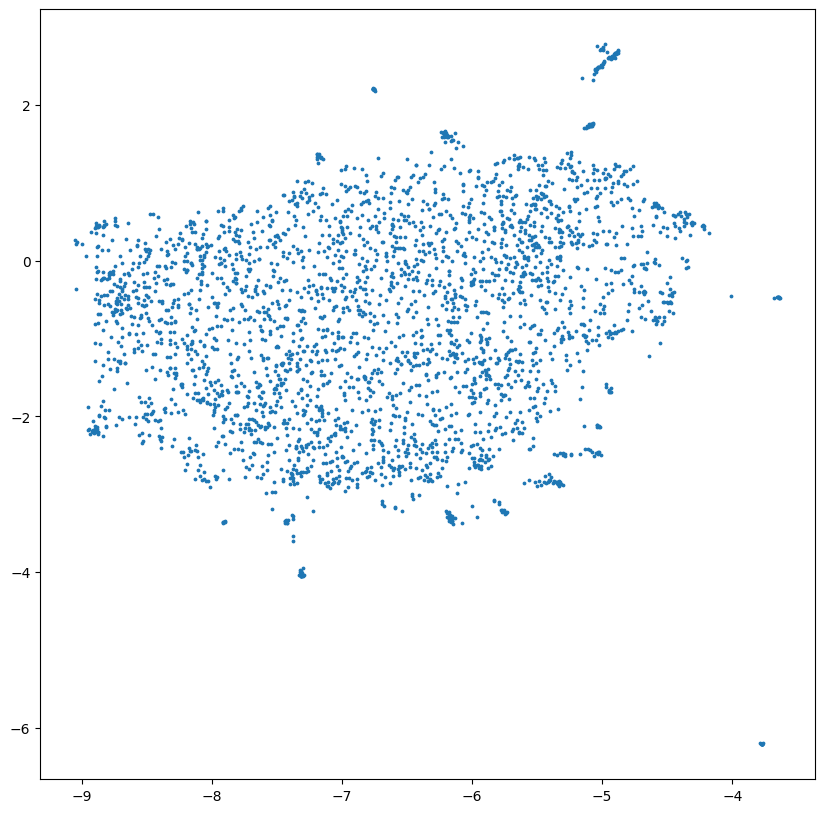

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(cluster_embedding[:,0],cluster_embedding[:,1],s=3)
plt.show()

In [ ]:
products = train_df[["StockCode","Description"]]
products.drop_duplicates(inplace=True,)
products_dict = products.groupby('StockCode')['Description'].apply(list).to_dict()
products_dict

/tmp/ipykernel_6295/3367788274.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



{'10002': ['INFLATABLE POLITICAL GLOBE '],
 '10080': ['GROOVY CACTUS INFLATABLE'],
 '10120': ['DOGGY RUBBER'],
 '10123C': ['HEARTS WRAPPING TAPE '],
 '10124A': ['SPOTS ON RED BOOKCOVER TAPE'],
 '10124G': ['ARMY CAMO BOOKCOVER TAPE'],
 '10125': ['MINI FUNKY DESIGN TAPES'],
 '10133': ['COLOURING PENCILS BROWN TUBE'],
 '10135': ['COLOURING PENCILS BROWN TUBE'],
 '11001': ['ASSTD DESIGN RACING CAR PEN'],
 '15030': ['FAN BLACK FRAME '],
 '15034': ['PAPER POCKET TRAVELING FAN '],
 '15036': ['ASSORTED COLOURS SILK FAN'],
 '15039': ['SANDALWOOD FAN'],
 '15044A': ['PINK PAPER PARASOL '],
 '15044B': ['BLUE PAPER PARASOL '],
 '15044C': ['PURPLE PAPER PARASOL'],
 '15044D': ['RED PAPER PARASOL'],
 '15056BL': ['EDWARDIAN PARASOL BLACK'],
 '15056N': ['EDWARDIAN PARASOL NATURAL'],
 '15056P': ['EDWARDIAN PARASOL PINK'],
 '15058A': ['BLUE POLKADOT GARDEN PARASOL'],
 '15058B': ['PINK POLKADOT GARDEN PARASOL'],
 '15058C': ['ICE CREAM DESIGN GARDEN PARASOL'],
 '15060B': ['FAIRY CAKE DESIGN UMBRELLA'],
 '16

In [ ]:
def similar_products(v,n = 6):
  ms = model.wv.similar_by_vector(v,topn= n+1)[1:]
  new_ms = []
  for j in ms:
    new_ms.append((products_dict[j[0]][0],j[1]))
  return new_ms

In [ ]:
similar_products(model.wv['22079'])

[('RIBBON REEL LACE DESIGN ', 0.6431094408035278),
 ('RIBBON REEL FLORA + FAUNA ', 0.6216174364089966),
 ('CHOCOLATE BOX RIBBONS ', 0.5746264457702637),
 ('RIBBON REEL STRIPES DESIGN ', 0.5690739154815674),
 ('SCANDINAVIAN REDS RIBBONS', 0.5580692291259766),
 ('SET 4 NURSERY DES ROUND BOXES', 0.5418888926506042)]